In [6]:
import nets
import copy
import numpy as np
import matplotlib.pyplot as plt

In [7]:
#Mismo sistema que para temporal difference pero sin politica definida

X = np.linspace(-5, 5, 101)   # estados discretos
A = np.linspace(-1, 1, 31)    # acciones discretas
print(A)

Q = np.zeros((len(X), len(A)))

def closest_state(x):
    return np.argmin(np.abs(X - x))

def step(x, u): #Recompensa un poco más sofisticada, añadiendo el parámetro done y una recompensa mayor si llega al objetivo
    x_next = x + u
    x_next = np.clip(x_next, -20, 20) 
    r = -x_next**2 - 0.05 * u**2
    done = (abs(x_next) < 0.05)
    if done:
        r += 50
    elif abs(x_next) > 9.5:
        r -= 50
        done = True
        
    return x_next, r, done

[-1.         -0.93333333 -0.86666667 -0.8        -0.73333333 -0.66666667
 -0.6        -0.53333333 -0.46666667 -0.4        -0.33333333 -0.26666667
 -0.2        -0.13333333 -0.06666667  0.          0.06666667  0.13333333
  0.2         0.26666667  0.33333333  0.4         0.46666667  0.53333333
  0.6         0.66666667  0.73333333  0.8         0.86666667  0.93333333
  1.        ]


In [8]:
buffer = nets.ReplayBuffer(5000, 1, 1)

Q = nets.QNet(n_a = 31, n_s = 1)
Q_target = copy.deepcopy(Q)

N = 20000
eps = 0.2
gamma = 0.95
lr = 0.001
batch_size = 64
update_rate = 2

Q_mean_history_rb = []
Q_std_history_rb = []

for i in range(N):
    x = np.random.uniform(-5.0,5.0)
    x = np.array([[x]])
    for t in range(40):
        q = Q.forward(x)

        if np.random.rand() < eps:
            a_idx = np.random.randint(len(A), dtype=np.int64)
        else:
            a_idx = np.argmax(q)


        u = A[a_idx]

        x_next, r, done = step(x, u)

        buffer.add(x, a_idx, r, x_next, done)

        x = x_next

        if buffer.size > batch_size and t % update_rate == 0:
            
            batch = buffer.sample(batch_size)
            q = Q.forward(batch[0].T)


            q_next_online = Q.predict(batch[3].T)
            best_action = np.argmax(q_next_online, axis=0)

            q_next = Q_target.predict(batch[3].T)
            max_q_next = q_next[best_action, np.arange(batch_size)]
            max_q_next = max_q_next.reshape(1, -1)


            td_target = batch[2].T + gamma * (1 - batch[4].T) * max_q_next
            td_target = np.clip(td_target, -100, 100)
            q_target = q.copy()
            idx = batch[1].astype(int).flatten()
            q_target[idx, np.arange(batch_size)] = td_target.flatten()

            Q.backward(q_target, idx)
            Q.update_weights(lr)

        if done:
            break

    if i % 500 == 0:
        Q_target = copy.deepcopy(Q)      
    
    
    if i % 100 == 0:
        xs = np.linspace(-5, 5, 50)
        Q_vals = []

        for x_test in xs:
            x_in = np.array([[x_test]])
            q = Q.forward(x_in)
            Q_vals.append(q)

        Q_vals = np.array(Q_vals)

        Q_mean_history_rb.append(np.mean(Q_vals))
        Q_std_history_rb.append(np.std(Q_vals))




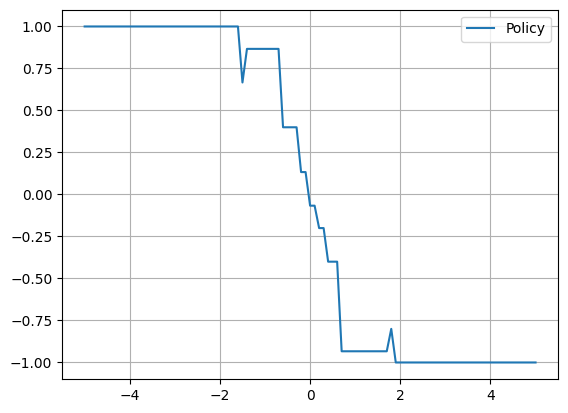

In [9]:
policy = np.array([
    A[np.argmax(Q.forward(np.array([[x]])))]
    for x in X
])

import matplotlib.pyplot as plt

plt.plot(X, policy)
plt.legend(["Policy"])
plt.grid()
plt.show()

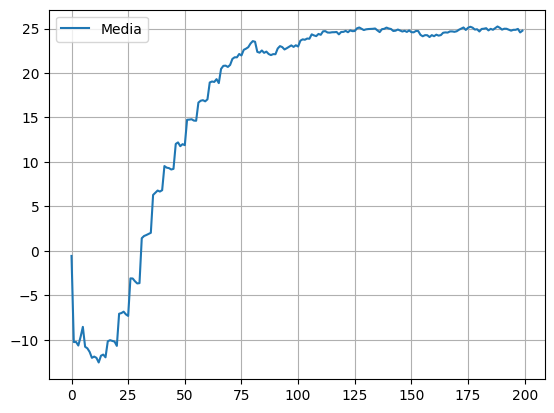

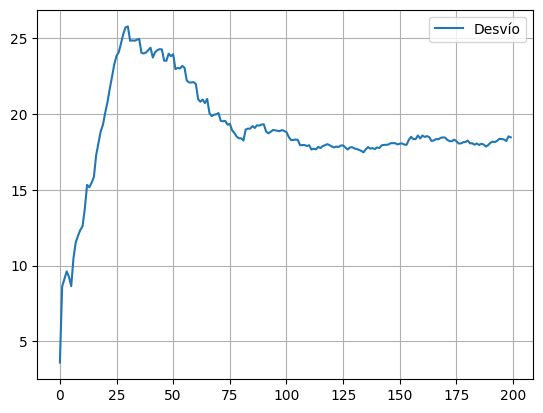

In [10]:
i = np.arange(0, len(Q_std_history_rb))

plt.plot(i, Q_mean_history_rb)
plt.legend(["Media"])
plt.grid()
plt.show()

plt.plot(i, Q_std_history_rb)
plt.legend(["Desvío"])
plt.grid()
plt.show()